In [1]:
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier # Notez: Classifier, pas Regressor
from sklearn.metrics import classification_report, confusion_matrix
from parametrage import tune_and_evaluate 
import pandas as pd
import numpy as np
from scratch_supervised import RandomForestScratch
import time


In [2]:
df = pd.read_csv('Cleaned_dataset/grid/MERGED_FINAL.csv')
df.head()

,spring_prec,autumn_prec,summer_prec,winter_prec,autumn_tmax,elevation,autumn_tmin,spring_tmax,summer_tmax,winter_tmin,...,CEC_SOIL,GYPSUM,BSAT,GRIDCODE_150.0,ALUM_SAT,GRIDCODE_50.0,GRIDCODE_151.0,ELEC_COND,GRIDCODE_110.0,fire_count
0,1.891892,1.866102,1.216560,-0.152672,-1.214286,0.942090,-1.2500,-0.666667,-0.666667,-1.250,...,-0.666667,-0.210526,0.045455,False,0.0,False,True,0.0,False,1.0
1,1.891892,1.866102,1.216560,-0.152672,-1.214286,0.942090,-1.2500,-0.666667,-0.666667,-1.250,...,-3.333333,-0.157895,-1.590909,False,0.0,False,True,0.0,False,1.0
2,1.891892,1.866102,1.216560,-0.152672,-1.214286,0.942090,-1.2500,-0.666667,-0.666667,-1.250,...,-0.666667,1.421053,0.000000,False,0.0,False,True,0.0,False,1.0
3,-0.430502,0.232203,0.764331,-0.233779,-0.642857,0.990113,-0.5625,-0.500000,-0.083333,-0.875,...,-0.666667,-0.210526,0.045455,False,0.0,False,True,0.0,False,0.0
4,-0.430502,0.232203,0.764331,-0.233779,-0.642857,0.990113,-0.5625,-0.500000,-0.083333,-0.875,...,-3.333333,-0.157895,-1.590909,False,0.0,False,True,0.0,False,0.0


In [3]:
# 1. Préparation (comme avant)
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

X = df.drop('fire_count', axis=1)

# --- TRANSFORMATION EN CLASSIFICATION ---
# Si fire_count > 0, alors 1 (Feu), sinon 0 (Pas de feu)
y = (df['fire_count'] > 0).astype(int)

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Note: 'stratify=y' assure qu'il y a la même proportion de feux dans le train et le test




In [4]:
train_df = X_train.copy()
train_df[y.name] = y_train  # On ajoute la colonne cible

test_df = X_test.copy()
test_df[y.name] = y_test    # On ajoute la colonne cible

# 4. Affichage pour vérification
print("--- Aperçu du DataFrame d'entraînement (train_df) ---")
print(f"Dimensions : {train_df.shape}")
print(train_df.head())

print("\n--- Aperçu du DataFrame de test (test_df) ---")
print(f"Dimensions : {test_df.shape}")
print(test_df.head())

--- Aperçu du DataFrame d'entraînement (train_df) ---
Dimensions : (681562, 40)
        spring_prec  autumn_prec  summer_prec  winter_prec  autumn_tmax  \
623374     0.592664     1.042373     0.605096     0.893130    -0.500000   
798751     5.826255     2.615254     1.649682     1.276718    -0.357143   
135490    -0.131274    -0.316949     2.331210    -0.004771    -0.642857   
703086     0.525096     0.838983    -0.031847     1.185115     0.500000   
823376     0.198842     0.767797    -0.133758     1.275763     0.928571   

        elevation  autumn_tmin  spring_tmax  summer_tmax  winter_tmin  ...  \
623374   0.440678      -0.1250    -0.750000    -0.166667      -0.2500  ...   
798751  -0.468927       0.0000    -0.416667    -1.583333       0.6250  ...   
135490   0.669492      -0.8750     0.000000    -0.166667      -0.7500  ...   
703086  -0.580508       0.4375     0.000000     0.166667       0.2500  ...   
823376  -0.673729       0.5625     0.250000    -0.166667       0.4375  ...   



In [5]:

rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [ 30, None],
    'min_samples_split': [5, 10],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

print("\n================= 🌳 GRID SEARCH: Random Forest =================\n")
rf_results = tune_and_evaluate(
    balanced_train_df=train_df,
    test_df=test_df,
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    target_col="fire_count",
    cv_folds=5,
    scoring="recall",
    )



================= 🌳 GRID SEARCH: Random Forest =================


...GridSearchCV...


Nolbres de combinations: 24

Combination Num_1/24
Params: {'class_weight': 'balanced', 'max_depth': 30, 'min_samples_split': 5, 'n_estimators': 50}
-----------------------------------
Metriques de la Cross-validation :
   • accuracy: 0.9941 
   • precision: 0.9699 
   • recall: 0.9469 
   • f1: 0.9582 
   • roc_auc: 0.9926
-----------------------------------

Combination Num_2/24
Params: {'class_weight': 'balanced', 'max_depth': 30, 'min_samples_split': 5, 'n_estimators': 100}
-----------------------------------
Metriques de la Cross-validation :
   • accuracy: 0.9942 
   • precision: 0.9710 
   • recall: 0.9473 
   • f1: 0.9590 
   • roc_auc: 0.9944
-----------------------------------

Combination Num_3/24
Params: {'class_weight': 'balanced', 'max_depth': 30, 'min_samples_split': 10, 'n_estimators': 50}
-----------------------------------
Metriques de la Cross-validation :
   • accuracy: 0.9939 
 

In [6]:
# 3. Entraînement avec ÉQUILIBRAGE
# Le paramètre class_weight='balanced' ajuste automatiquement les poids
rf_model = RandomForestClassifier(n_estimators=50, min_samples_split=2, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# 4. Évaluation
y_pred = rf_model.predict(X_test)

print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

Matrice de confusion :
[[157804    348]
 [   666  11573]]

Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    158152
           1       0.97      0.95      0.96     12239

    accuracy                           0.99    170391
   macro avg       0.98      0.97      0.98    170391
weighted avg       0.99      0.99      0.99    170391



C:\Users\melom\AppData\Local\Temp\ipykernel_9716\128492051.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp, y=feature_imp.index, palette="viridis")


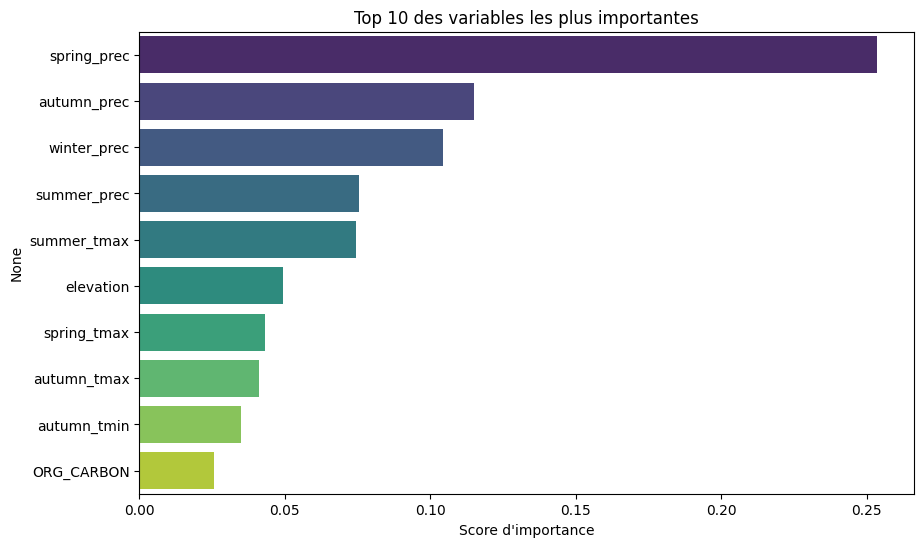

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Récupération des importances
feature_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

# Affichage graphique
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp, y=feature_imp.index, palette="viridis")
plt.title("Top 10 des variables les plus importantes")
plt.xlabel("Score d'importance")
plt.show()

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print(classification_report(y_test, y_pred, zero_division=0))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9940489814602884
Precision: 0.9708078181360624
Recall: 0.945583789525288
F1: 0.9580298013245033
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    158152
           1       0.97      0.95      0.96     12239

    accuracy                           0.99    170391
   macro avg       0.98      0.97      0.98    170391
weighted avg       0.99      0.99      0.99    170391


Confusion Matrix:
[[157804    348]
 [   666  11573]]


In [9]:

# 1. Fixer l'aléatoire pour la reproductibilité (comme random_state=42)
np.random.seed(42)

# 2. Chargement des données
print("Chargement des données...")
X_train = pd.read_csv('Cleaned_dataset/Balanced_data/X_train_bal.csv').values
y_train = pd.read_csv('Cleaned_dataset/Balanced_data/y_train_bal.csv').values.ravel() # .ravel() pour aplatir
X_test = pd.read_csv('Cleaned_dataset/Balanced_data/X_test.csv').values
y_test = pd.read_csv('Cleaned_dataset/Balanced_data/y_test.csv').values.ravel()

# 3. Initialisation avec les paramètres proches de Sklearn
print("Initialisation du modèle...")
rf = RandomForestScratch(
    n_trees=50,            # Comme n_estimators=50
    max_depth=20,           # Assez profond pour imiter Sklearn
    min_samples_split=10,    # Défaut Sklearn
)

# 4. Entraînement (avec mesure du temps)
start_time = time.time()
print(f"Début de l'entraînement de {rf.n_trees} arbres sur {len(X_train)} lignes.")
print("Cela peut être long, prenez un café... ☕")

rf.fit(X_train, y_train)

end_time = time.time()
print(f"Entraînement terminé en {(end_time - start_time)/60:.2f} minutes.")

# 5. Prédiction
print("Calcul des prédictions...")
y_pred = rf.predict(X_test)

# 6. Calcul des Métriques (Accuracy & Recall)
# Accuracy
accuracy = np.mean(y_test == y_pred)

# Recall (Calcul manuel : TP / (TP + FN))
tp = np.sum((y_test == 1) & (y_pred == 1))
fn = np.sum((y_test == 1) & (y_pred == 0))
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print("-" * 30)
print("RÉSULTATS DU MODÈLE FROM SCRATCH")
print("-" * 30)
print(f"Accuracy : {accuracy:.4f} (ou {accuracy*100:.2f}%)")
print(f"Recall   : {recall:.4f}   (ou {recall*100:.2f}%)")
print("-" * 30)

# Matrice de confusion simple
tn = np.sum((y_test == 0) & (y_pred == 0))
fp = np.sum((y_test == 0) & (y_pred == 1))
print(f"Matrice :\n[[{tn}  {fp}]\n [{fn}   {tp}]]")

Chargement des données...
Initialisation du modèle...
Début de l'entraînement de 50 arbres sur 615206 lignes.
Cela peut être long, prenez un café... ☕
Arbre 1/50 entraîné.
Arbre 2/50 entraîné.
Arbre 3/50 entraîné.
Arbre 4/50 entraîné.
Arbre 5/50 entraîné.
Arbre 6/50 entraîné.
Arbre 7/50 entraîné.
Arbre 8/50 entraîné.
Arbre 9/50 entraîné.
Arbre 10/50 entraîné.
Arbre 11/50 entraîné.
Arbre 12/50 entraîné.
Arbre 13/50 entraîné.
Arbre 14/50 entraîné.
Arbre 15/50 entraîné.
Arbre 16/50 entraîné.
Arbre 17/50 entraîné.
Arbre 18/50 entraîné.
Arbre 19/50 entraîné.
Arbre 20/50 entraîné.
Arbre 21/50 entraîné.
Arbre 22/50 entraîné.
Arbre 23/50 entraîné.
Arbre 24/50 entraîné.
Arbre 25/50 entraîné.
Arbre 26/50 entraîné.
Arbre 27/50 entraîné.
Arbre 28/50 entraîné.
Arbre 29/50 entraîné.
Arbre 30/50 entraîné.
Arbre 31/50 entraîné.
Arbre 32/50 entraîné.
Arbre 33/50 entraîné.
Arbre 34/50 entraîné.
Arbre 35/50 entraîné.
Arbre 36/50 entraîné.
Arbre 37/50 entraîné.
Arbre 38/50 entraîné.
Arbre 39/50 entraîné.


In [10]:

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print(classification_report(y_test, y_pred, zero_division=0))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9940959322968936
Precision: 0.9773905652358691
Recall: 0.9395375439169866
F1: 0.9580903182802866
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    158152
         1.0       0.98      0.94      0.96     12239

    accuracy                           0.99    170391
   macro avg       0.99      0.97      0.98    170391
weighted avg       0.99      0.99      0.99    170391


Confusion Matrix:
[[157886    266]
 [   740  11499]]
